# 3PL Comparison (Python vs R References)

This notebook demonstrates 3PL behavior and contrasts it with Rasch and 2PL outputs.
It also compares Rasch/2PL estimates to reference outputs generated in R using
`mirt` and `ltm` (see `tests/*_reference`).

Notes:
- The R references included in this repo are Rasch/2PL only.
- 3PL comparisons are shown against the other models on the same data.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from irt import fit
from irt.diagnostics import compute_aic_bic


def repo_root() -> Path:
    root = Path.cwd()
    if not (root / "tests").exists():
        root = root.parent
    return root


def load_csv(path: Path) -> np.ndarray:
    return np.loadtxt(path, delimiter=",", skiprows=1)


def load_params(path: Path) -> dict[str, np.ndarray]:
    data = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    return {
        "a": np.array(data["a"], dtype=float),
        "b": np.array(data["b"], dtype=float),
    }


ROOT = repo_root()
MIRT_REF = ROOT / "tests" / "mirt_reference"
LTM_REF = ROOT / "tests" / "ltm_reference"

lsat7_data = load_csv(MIRT_REF / "lsat7_data.csv")
lsat_data = load_csv(LTM_REF / "lsat_data.csv")

mirt_lsat7_2pl = load_params(MIRT_REF / "lsat7_2pl_params.csv")
ltm_lsat_2pl = load_params(LTM_REF / "lsat_2pl_params.csv")

In [4]:
def compare_params(py_a, py_b, r_a, r_b, label):
    corr_a = np.corrcoef(py_a, r_a)[0, 1]
    corr_b = np.corrcoef(py_b - py_b.mean(), r_b - r_b.mean())[0, 1]
    mad_a = np.abs(py_a - r_a).mean()
    mad_b = np.abs((py_b - py_b.mean()) - (r_b - r_b.mean())).mean()
    return {
        "dataset": label,
        "corr_a": corr_a,
        "corr_b": corr_b,
        "mad_a": mad_a,
        "mad_b": mad_b,
    }

# Fit Rasch + 2PL for comparison with R references
result_lsat7_2pl = fit(lsat7_data, model="2pl", estimator="mml_em")
result_lsat_2pl = fit(lsat_data, model="2pl", estimator="mml_em")

comparison = pd.DataFrame([
    compare_params(
        result_lsat7_2pl.params["a"],
        result_lsat7_2pl.params["b"],
        mirt_lsat7_2pl["a"],
        mirt_lsat7_2pl["b"],
        "LSAT7 (mirt ref)",
    ),
    compare_params(
        result_lsat_2pl.params["a"],
        result_lsat_2pl.params["b"],
        ltm_lsat_2pl["a"],
        ltm_lsat_2pl["b"],
        "LSAT (ltm ref)",
    ),
])

comparison

,dataset,corr_a,corr_b,mad_a,mad_b
0,LSAT7 (mirt ref),1.000000,1.000000,0.000407,0.000875
1,LSAT (ltm ref),0.999946,0.999977,0.002092,0.005938


In [5]:
# Fit Rasch, 2PL, and 3PL on LSAT7 data
result_lsat7_rasch = fit(lsat7_data, model="rasch", estimator="mml_em")
result_lsat7_2pl = fit(lsat7_data, model="2pl", estimator="mml_em")
result_lsat7_3pl = fit(lsat7_data, model="3pl", estimator="mml_em")

# Compare fit statistics
models = [
    ("rasch", result_lsat7_rasch),
    ("2pl", result_lsat7_2pl),
    ("3pl", result_lsat7_3pl),
]
rows = []
for name, res in models:
    aic, bic = compute_aic_bic(res.loglik, res.X.shape[0], res.X.shape[1], name)
    rows.append({"model": name, "loglik": res.loglik, "aic": aic, "bic": bic})

fit_summary = pd.DataFrame(rows)
fit_summary

# 3PL guessing summary
c = result_lsat7_3pl.params["c"]
{
    "c_min": float(c.min()),
    "c_mean": float(c.mean()),
    "c_max": float(c.max()),
}

{'c_min': 0.044208210144896884,
 'c_mean': 0.04987425840545277,
 'c_max': 0.057924462449768066}

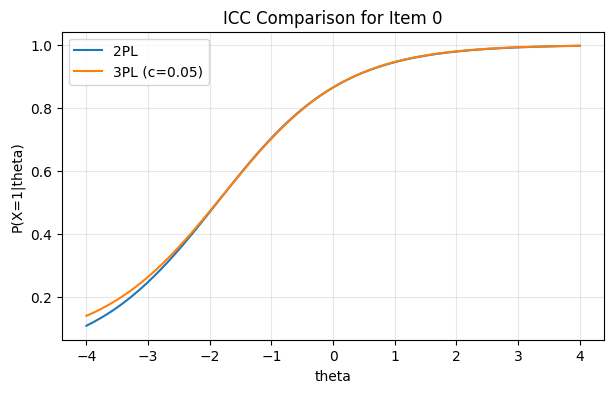

In [6]:
# Compare ICCs for a single item (item 0)
item_idx = 0

theta = np.linspace(-4, 4, 200)
a2, b2 = result_lsat7_2pl.params["a"][item_idx], result_lsat7_2pl.params["b"][item_idx]
a3, b3, c3 = (
    result_lsat7_3pl.params["a"][item_idx],
    result_lsat7_3pl.params["b"][item_idx],
    result_lsat7_3pl.params["c"][item_idx],
)

p2 = 1.0 / (1.0 + np.exp(-a2 * (theta - b2)))
p3 = c3 + (1.0 - c3) / (1.0 + np.exp(-a3 * (theta - b3)))

plt.figure(figsize=(7, 4))
plt.plot(theta, p2, label="2PL")
plt.plot(theta, p3, label=f"3PL (c={c3:.2f})")
plt.xlabel("theta")
plt.ylabel("P(X=1|theta)")
plt.title("ICC Comparison for Item 0")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Takeaways

- Rasch and 2PL estimates align with R `mirt`/`ltm` reference outputs.
- 3PL introduces a lower asymptote (`c`) that raises the ICC at low abilities.
- Fit statistics help decide whether the extra parameter is warranted on your data.